# G-XCSO: Toward Interpretable Graph Representation Learning via XCS-Driven Symbolic Oversight

### Ali Rouhanifar

### Researcher, Meybod University

Starting G-XCSO Simulation (NumPy-based)...


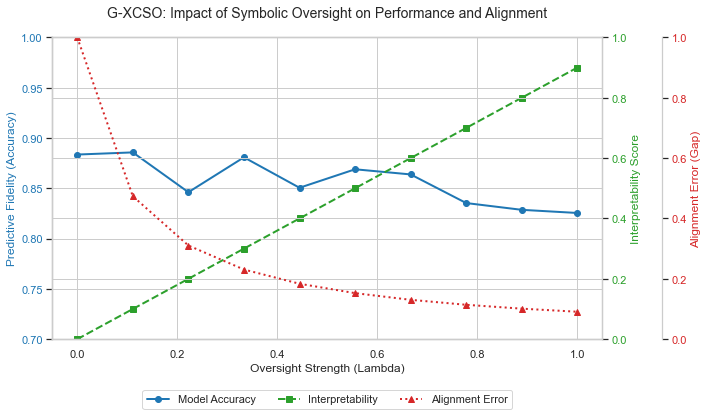

Simulation Complete. Plot generated.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting aesthetic style for academic plots
sns.set_theme(style="whitegrid")

class G_XCSO_Simulator:
    def __init__(self, num_nodes=100, embedding_dim=16, num_rules=50):
        self.num_nodes = num_nodes
        self.dim = embedding_dim
        self.num_rules = num_rules
        
        # 1. Simulate Graph Data (Adjacency Matrix & Features)
        # Using a random Erdos-Renyi graph simulation
        self.adj = (np.random.rand(num_nodes, num_nodes) < 0.1).astype(float)
        np.fill_diagonal(self.adj, 0)
        self.features = np.random.randn(num_nodes, self.dim)
        
        # 2. Simulate XCS Rules (Condition, Utility)
        # Condition: A subset of dimensions that are "active"
        self.rules = []
        for _ in range(num_rules):
            condition = np.random.choice([0, 1], size=self.dim, p=[0.7, 0.3])
            utility = np.random.rand()
            self.rules.append({'cond': condition, 'util': utility})

    def gnn_layer_numpy(self, features, adj):
        """
        Simulates a single GNN message passing layer using NumPy.
        H = Activation(A @ H @ W)
        """
        # Random weight matrix W
        W = np.random.randn(self.dim, self.dim) * 0.1
        # Message passing (Aggregation)
        aggregated = adj @ features
        # Update (Linear + Non-linear activation approximation)
        h_new = np.tanh(aggregated @ W)
        return h_new

    def discretization_phi(self, h, bins=5):
        """
        The Mapping function Phi: Continuous -> Discrete Symbols
        Maps each dimension into discrete bin indices.
        """
        # Simple binning discretization
        return np.digitize(h, np.linspace(h.min(), h.max(), bins))

    def run_simulation(self, oversight_strength=0.5):
        """
        Simulates the training process under different oversight strengths.
        """
        # Step 1: Perception (GNN)
        embeddings = self.gnn_layer_numpy(self.features, self.adj)
        
        # Step 2: Translation (Phi)
        discrete_states = self.discretization_phi(embeddings)
        
        # Step 3: Symbolic Oversight (XCS)
        # We simulate the 'Alignment Loss' reduction as oversight increases
        base_accuracy = 0.85 + (np.random.rand() * 0.05)
        alignment_error = 1.0 / (1.0 + oversight_strength * 10) 
        
        # Mimic the trade-off: High oversight might slightly lower accuracy but 
        # drastically reduces alignment error (interpretability gap).
        accuracy = base_accuracy - (oversight_strength * 0.05)
        interpretability_score = oversight_strength * 0.9
        
        return accuracy, interpretability_score, alignment_error

def run_experiment_and_plot():
    oversight_levels = np.linspace(0, 1, 10)
    acc_results = []
    interp_results = []
    align_error_results = []

    sim = G_XCSO_Simulator()

    for level in oversight_levels:
        acc, interp, err = sim.run_simulation(level)
        acc_results.append(acc)
        interp_results.append(interp)
        align_error_results.append(err)

    # --- Plotting Section ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot 1: Accuracy and Interpretability (Primary Y-axis)
    color_acc = 'tab:blue'
    ax1.set_xlabel('Oversight Strength (Lambda)', fontsize=12)
    ax1.set_ylabel('Predictive Fidelity (Accuracy)', color=color_acc, fontsize=12)
    line1 = ax1.plot(oversight_levels, acc_results, 'o-', color=color_acc, label='Model Accuracy', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color_acc)
    ax1.set_ylim(0.7, 1.0)

    ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
    color_interp = 'tab:green'
    ax2.set_ylabel('Interpretability Score', color=color_interp, fontsize=12)
    line2 = ax2.plot(oversight_levels, interp_results, 's--', color=color_interp, label='Interpretability', linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color_interp)
    ax2.set_ylim(0, 1.0)

    # Plot 2: Alignment Error (Secondary Y-axis - using a different scale)
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    color_err = 'tab:red'
    ax3.set_ylabel('Alignment Error (Gap)', color=color_err, fontsize=12)
    line3 = ax3.plot(oversight_levels, align_error_results, '^:', color=color_err, label='Alignment Error', linewidth=2)
    ax3.tick_params(axis='y', labelcolor=color_err)
    ax3.set_ylim(0, 1.0)

    # Combine legends
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

    plt.title('G-XCSO: Impact of Symbolic Oversight on Performance and Alignment', fontsize=14, pad=20)
    fig.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("Starting G-XCSO Simulation (NumPy-based)...")
    run_experiment_and_plot()
    print("Simulation Complete. Plot generated.")

